In [31]:
import numpy as np
import matplotlib.pyplot as plt
import gc

## 1. Fashion MNIST Sample 그려보기

각 class 별로 한 개 씩의 sample을 뽑아서 그림을 그려봅니다.

In [21]:
# import tensorflow 
import tensorflow as tf
from tensorflow.keras import datasets, models
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPool2D
from tensorflow.keras.utils import plot_model

# tensorflow 버전 확인
print(tf.__version__)

2.21.0


In [22]:
# Fashion MNIST 불러오기
fashion_mnist = datasets.fashion_mnist
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()
# 학습 및 테스트 이미지 정규화
train_x = train_x/255.0
test_x = test_x/255.0

# 학습 및 테스트 데이터의 이미지와 정답 레이블 배열 형태(shape) 확인
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


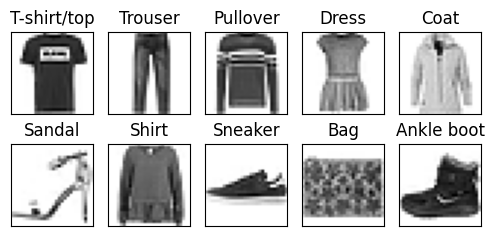

In [23]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(5, 2.5))

for class_id in range(10):
    # 해당 클래스에 속하는 첫 번째 이미지의 인덱스
    index = np.where(train_y == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(train_x[index], cmap=plt.cm.binary)
    plt.title(class_names[class_id])
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

## 2. Fashion MNIST(or CIFAR10)를 분류하는 CNN 학습하기

CNN이 image data에서 DNN에 비해 얼마나 뛰어난지를 확인하는 것이 목표입니다.  
모수의 수가 비슷한 DNN과 CNN을 구축한 뒤 데이터를 이용하여 각각의 모형을 학습하고 test accuracy를 비교합니다.

In [24]:
## DNN model을 구축합니다.
dnn_model = models.Sequential([
  Flatten(input_shape=(28,28)),
  Dense(110, activation='relu'),
  Dense(100, activation='relu'),
  Dense(10, activation='softmax')]
)

dnn_model.summary()

d:\python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 110)            │        86,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        11,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,460 (384.61 KB)

 Trainable params: 98,460 (384.61 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Adam 최적화 알고리즘과 정수 레이블용 다중 분류 손실 함수를 설정하고, 정확도로 성능 평가
dnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습 데이터의 10%를 검증용으로 분리하고, 나머지를 배치 크기 100으로 20회 학습하여 기록 저장
dnn_hist = dnn_model.fit(train_x, train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8142 - loss: 0.5372 - val_accuracy: 0.8517 - val_loss: 0.4134
Epoch 2/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8607 - loss: 0.3879 - val_accuracy: 0.8622 - val_loss: 0.3720
Epoch 3/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8735 - loss: 0.3462 - val_accuracy: 0.8622 - val_loss: 0.3712
Epoch 4/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8828 - loss: 0.3216 - val_accuracy: 0.8788 - val_loss: 0.3377
Epoch 5/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8876 - loss: 0.3051 - val_accuracy: 0.8713 - val_loss: 0.3506
Epoch 6/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8940 - loss: 0.2873 - val_accuracy: 0.8770 - val_loss: 0.3329
Epoch 7/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8971 - loss: 0.2767 - val_accuracy: 0.8680 - val_loss: 0.3619
Epoch 8/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9024 - loss: 0.2632 - val_accuracy: 0.

In [13]:
# DNN 모델을 평가합니다.
dnn_sc = dnn_model.evaluate(test_x, test_y)

print('Performance of DNN')
print('...test accuracy: %.3f, test loss: %.3f'%(dnn_sc[1], dnn_sc[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.8813 - loss: 0.3726
Performance of DNN
...test accuracy: 0.881, test loss: 0.373


In [14]:
# CNN 모델에서 사용하기 위해 Data shape을 변경합니다.
ext_train_x = train_x.reshape((60000, 28, 28, 1))
ext_test_x = test_x.reshape((10000, 28, 28, 1))

In [16]:
## CNN model을 구축합니다.
cnn_model = models.Sequential([
  Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
  MaxPool2D(pool_size=(2, 2), strides=(2,2), padding='valid'),
  Conv2D(64, (3, 3), activation='relu'),
  MaxPool2D(pool_size=(2, 2), strides=(2,2), padding='valid'),
  Conv2D(64, (3, 3), activation='relu'),
  Flatten(),
  Dense(64, activation='relu'),
  Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Adam 최적화 알고리즘과 정수 레이블용 다중 분류 손실 함수를 설정하고, 정확도로 성능 평가
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습 데이터의 10%를 검증용으로 분리하고, 나머지를 배치 크기 100으로 20회 학습하여 기록 저
cnn_hist=cnn_model.fit(ext_train_x, train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7866 - loss: 0.5899 - val_accuracy: 0.8377 - val_loss: 0.4332
Epoch 2/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8654 - loss: 0.3720 - val_accuracy: 0.8713 - val_loss: 0.3457
Epoch 3/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8839 - loss: 0.3198 - val_accuracy: 0.8877 - val_loss: 0.3147
Epoch 4/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8958 - loss: 0.2877 - val_accuracy: 0.8793 - val_loss: 0.3417
Epoch 5/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9019 - loss: 0.2676 - val_accuracy: 0.8960 - val_loss: 0.2802
Epoch 6/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9087 - loss: 0.2475 - val_accuracy: 0.9013 - val_loss: 0.2711
Epoch 7/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9158 - loss: 0.2275 - val_accuracy: 0.8933 - val_loss: 0.2972
Epoch 8/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9200 - loss: 0.2154 - val_accu

In [18]:
# CNN 모델을 평가합니다.
cnn_sc = cnn_model.evaluate(ext_test_x, test_y)

print('Performance of CNN')
print('...test accuracy: %.3f, test loss: %.3f'%(cnn_sc[1], cnn_sc[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9085 - loss: 0.3234
Performance of CNN
...test accuracy: 0.909, test loss: 0.323


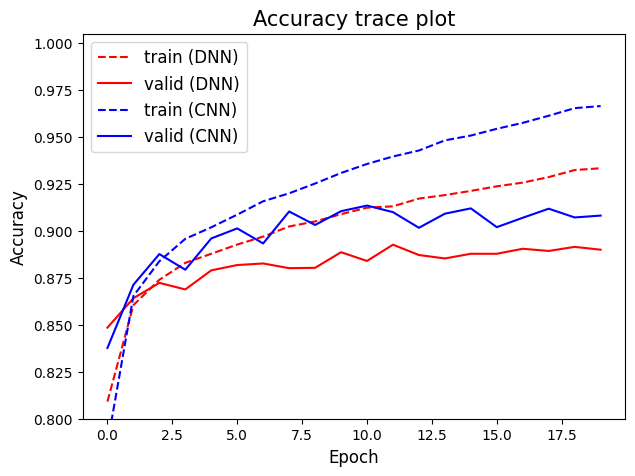

In [19]:
# DNN, CNN 모델의 결과를 비교합니다.
plt.figure(figsize=(7,5))
plt.plot(dnn_hist.history['accuracy'], 'r--', label='train (DNN)')
plt.plot(dnn_hist.history['val_accuracy'], 'r-', label='valid (DNN)')
plt.plot(cnn_hist.history['accuracy'], 'b--', label='train (CNN)')
plt.plot(cnn_hist.history['val_accuracy'], 'b-', label='valid (CNN)')
plt.ylim([0.8,1.005])
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.title('Accuracy trace plot', fontsize=15)
plt.show()

## 3. 전이학습 활용해보기

전이학습을 실제로 활용해보는 것을 목표로 합니다.  
InceptionV3을 이용하여 CIFAR10의 feature vector를 구축하고  
이 feature vector를 이용하여 multi-class logistic regression model을 학습합니다.  
이 모형의 결과를 앞서 CNN으로 학습한 모형의 결과와 비교해봅니다.

앞서 Fashion MNIST를 DNN, CNN으로 학습했습니다.  
전이학습결과와의 비교를 위해서 CIFAR10을 CNN으로 학습합니다.

In [27]:
import keras
from keras.datasets import cifar10
from keras.applications.inception_v3 import InceptionV3, preprocess_input

In [53]:
# CIFAR10 data를 load 합니다.
(train_x, train_y), (test_x, test_y) = cifar10.load_data()
print(train_y.shape)
train_y = np.squeeze(train_y)
print(train_y.shape)
test_y = np.squeeze(test_y)

(50000, 1)
(50000,)


d:\python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()


In [54]:
# InceptionV3를 이용하기 위해서 이미지 크기를 32*32*3 에서 75*75*3으로 변환합니다.
train_images = tf.constant(train_x, dtype=tf.float32)
big_train_x = tf.image.resize(train_images, [75,75]).numpy()
print(big_train_x.shape)

test_images = tf.constant(test_x, dtype=tf.float32)
big_test_x = tf.image.resize(test_images, [75,75]).numpy()
print(big_test_x.shape)

(50000, 75, 75, 3)
(10000, 75, 75, 3)


In [55]:
# 학습 및 테스트 이미지 정규화
big_train_x = big_train_x/255.0
big_test_x = big_test_x/255.0

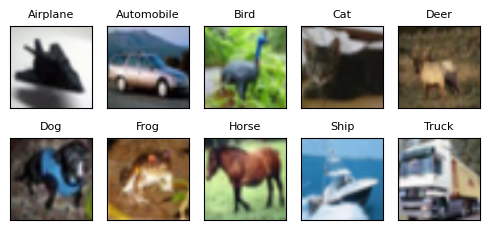

In [56]:
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

labels = np.asarray(train_y).reshape(-1)
plt.figure(figsize=(5, 2.5))

for class_id in range(10):
    # 해당 클래스에 속하는 첫 번째 이미지의 인덱스
    index = np.where(labels == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(big_train_x[index])
    plt.title(class_names[class_id], fontsize=8)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [57]:
## CNN model을 구축합니다.
cnn_model = models.Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(75, 75, 3)),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.summary()

d:\python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 73, 73, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,634 (3.73 MB)

 Trainable params: 978,634 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Adam 최적화 알고리즘과 정수 레이블용 다중 분류 손실 함수를 설정하고, 정확도로 성능 평가
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습 데이터의 10%를 검증용으로 분리하고, 나머지를 배치 크기 100으로 20회 학습하여 기록 저
cnn_hist=cnn_model.fit(big_train_x, train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 44s 97ms/step - accuracy: 0.3169 - loss: 2.4851 - val_accuracy: 0.4010 - val_loss: 1.6380
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.4549 - loss: 1.5112 - val_accuracy: 0.4902 - val_loss: 1.4220
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.5285 - loss: 1.3161 - val_accuracy: 0.5234 - val_loss: 1.3418
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.5990 - loss: 1.1361 - val_accuracy: 0.5508 - val_loss: 1.2897
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 47s 104ms/step - accuracy: 0.6578 - loss: 0.9749 - val_accuracy: 0.5800 - val_loss: 1.2365
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.7168 - loss: 0.8092 - val_accuracy: 0.5776 - val_loss: 1.2934
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - accuracy: 0.7642 - loss: 0.6666 - val_accuracy: 0.5792 - val_loss: 1.4755
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.8150 - loss: 0.5

In [48]:
# CNN 모델을 평가합니다.
cnn_sc = cnn_model.evaluate(big_test_x, test_y)

print('Performance of CNN')
print('...test accuracy: %.3f, test loss: %.3f'%(cnn_sc[1], cnn_sc[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5439 - loss: 3.9616
Performance of CNN
...test accuracy: 0.544, test loss: 3.962


In [58]:
## load inceptionV3 model
model = InceptionV3(weights='imagenet', include_top=False, input_shape=(75, 75, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [59]:
## extract the penultimate features
## train data
train_features = model.predict(big_train_x)
print(train_features.shape)
train_features = np.squeeze(train_features)
print(train_features.shape)

## test data
test_features = model.predict(big_test_x)
print(test_features.shape)
test_features = np.squeeze(test_features)
print(test_features.shape)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 56ms/step
(50000, 1, 1, 2048)
(50000, 2048)
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step
(10000, 1, 1, 2048)
(10000, 2048)


In [60]:
multi_logistic_model = models.Sequential([
  Dense(10, activation='softmax', input_shape=(2048,))]
)
multi_logistic_model.summary()

d:\python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,490 (80.04 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
multi_logistic_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist=multi_logistic_model.fit(train_features, train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5335 - loss: 1.3800 - val_accuracy: 0.5848 - val_loss: 1.2010
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6192 - loss: 1.1266 - val_accuracy: 0.5918 - val_loss: 1.1634
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6369 - loss: 1.0702 - val_accuracy: 0.5960 - val_loss: 1.1566
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6424 - loss: 1.0392 - val_accuracy: 0.6022 - val_loss: 1.1481
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6493 - loss: 1.0179 - val_accuracy: 0.5948 - val_loss: 1.1726
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6553 - loss: 1.0024 - val_accuracy: 0.6018 - val_loss: 1.1505
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6583 - loss: 0.9898 - val_accuracy: 0.6010 - val_loss: 1.1694
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6606 - loss: 0.9798 - val_accuracy: 0.

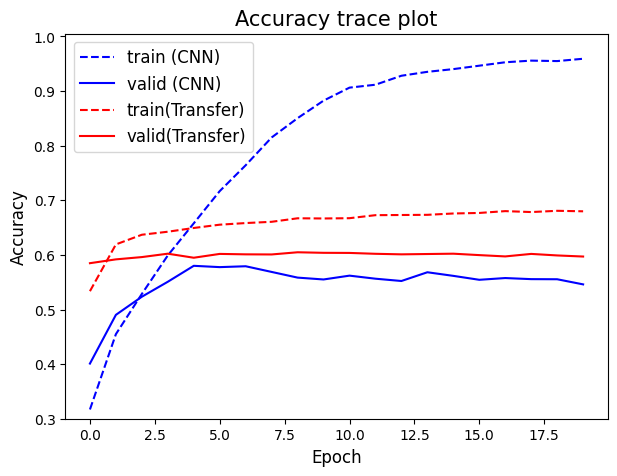

In [64]:
# CNN, Transfer-Learning 모델의 결과를 비교합니다.
plt.figure(figsize=(7,5))
plt.plot(cnn_hist.history['accuracy'], 'b--', label='train (CNN)')
plt.plot(cnn_hist.history['val_accuracy'], 'b-', label='valid (CNN)')
plt.plot(hist.history['accuracy'], 'r--', label='train(Transfer)')
plt.plot(hist.history['val_accuracy'], 'r-', label='valid(Transfer)')
plt.ylim([0.3,1.005])
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.title('Accuracy trace plot', fontsize=15)
plt.show()